# Replicating Santos experiment

Here we plot the timing relationship between presynaptic activation of glutamate and the dopamine pulse.

In [1]:
import os
import numpy as np

network_path = os.path.join("networks", "santos_fig3")
simulation_file = os.path.join(network_path, "simulation", "output.hdf5")


In [2]:
from snudda.plotting.plot_simulation_reaction_diffusion import PlotReactionDiffusion

# By passing the sls object we avoid loading it twice
prd = PlotReactionDiffusion(network_path=network_path,
                            simulation_file=simulation_file)

for i in range(0,10):
    print(f"Neuron {i} has data: {prd.list_neuron_info(i)}\n\n")

Loading networks/santos_fig3/simulation/output.hdf5
Neuron 0 has data: ['D1R', 'DA', 'PP1', 'cal', 'cal12_ms.modulation_factor', 'cal13_ms.modulation_factor', 'car_ms.modulation_factor', 'kaf_ms.modulation_factor_g', 'kaf_ms.modulation_factor_shift', 'kas_ms.modulation_factor', 'kir_ms.modulation_factor', 'naf_ms.modulation_factor', 'pSubstrate', 'sk_ms.modulation_factor', 'spikes', 'synapse_modulation_factor_ampa', 'synapse_modulation_factor_nmda', 'voltage']


Neuron 1 has data: ['D1R', 'DA', 'PP1', 'cal', 'cal12_ms.modulation_factor', 'cal13_ms.modulation_factor', 'car_ms.modulation_factor', 'kaf_ms.modulation_factor_g', 'kaf_ms.modulation_factor_shift', 'kas_ms.modulation_factor', 'kir_ms.modulation_factor', 'naf_ms.modulation_factor', 'pSubstrate', 'sk_ms.modulation_factor', 'spikes', 'synapse_modulation_factor_ampa', 'synapse_modulation_factor_nmda', 'voltage']


Neuron 2 has data: ['D1R', 'DA', 'PP1', 'cal', 'cal12_ms.modulation_factor', 'cal13_ms.modulation_factor', 'car_ms.mod

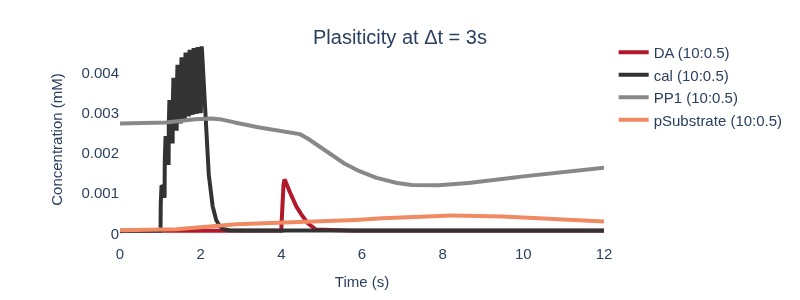

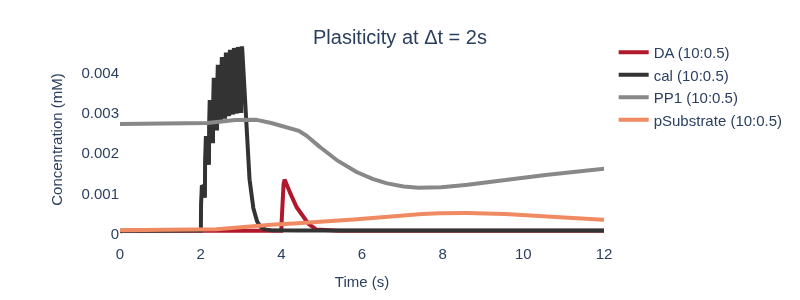

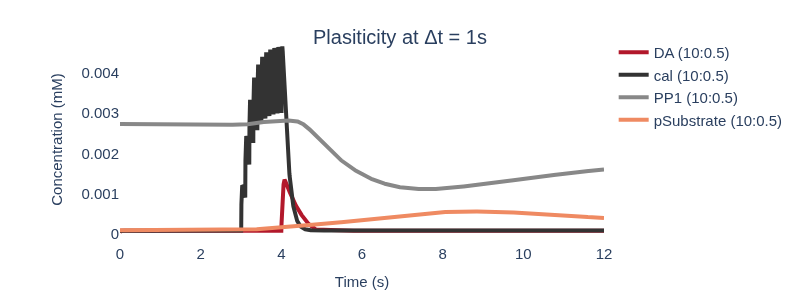

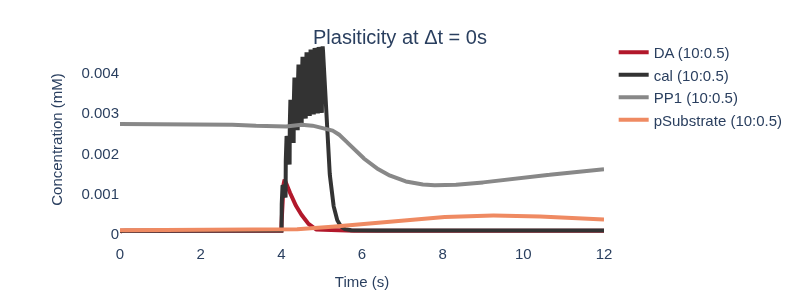

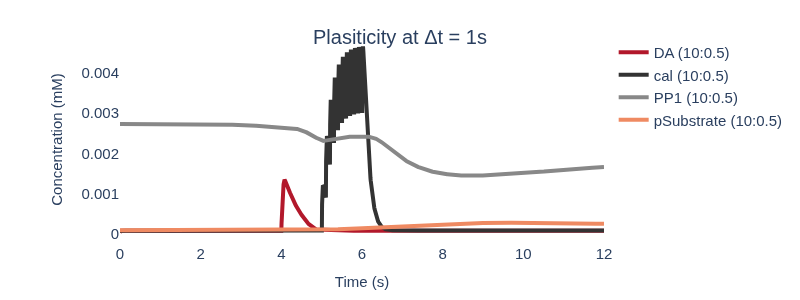

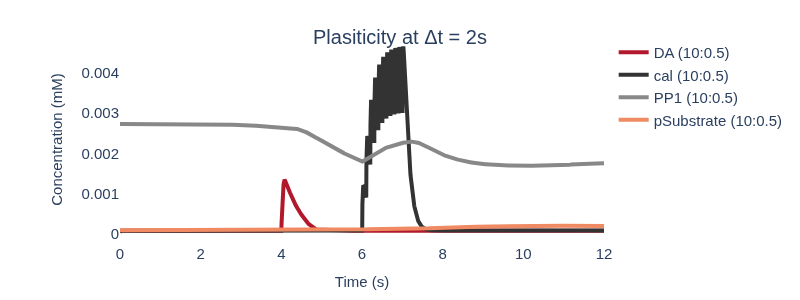

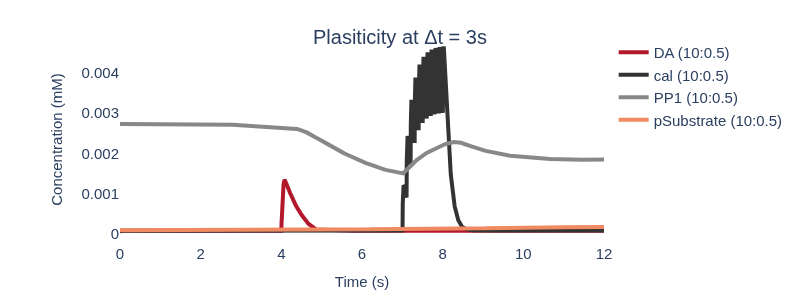

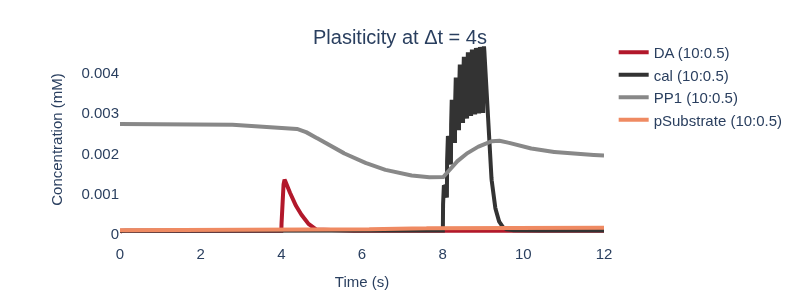

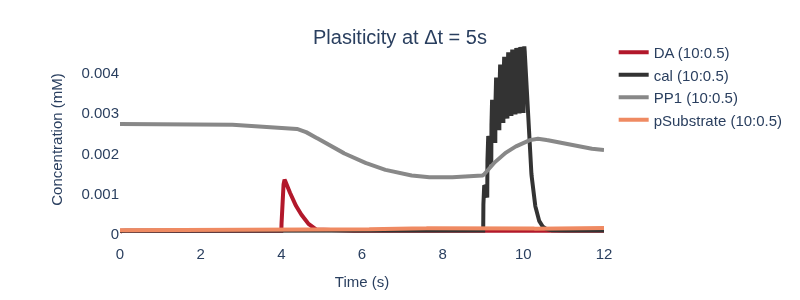

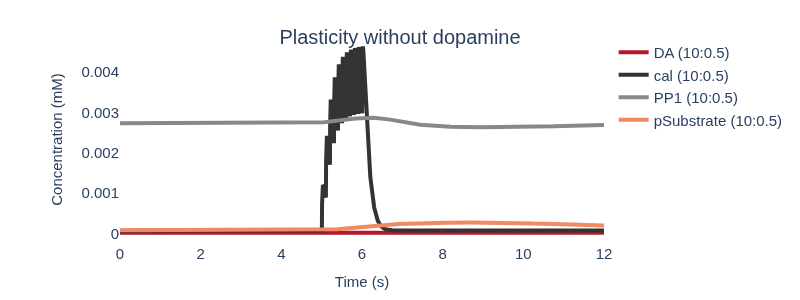

In [39]:
colour_dict = {"DA": '#b2182b', "cal": '#333333',  "PP1": "#888888", "pSubstrate": '#ef8a62'}

# We do normalisation manually, since we want the same normalisation in both 4 and 20Hz plots for comparison, so have manually
# extracted the peak values:
#
# import h5py, numpy as np
# xx = h5py.File("output_neuromodulation_ON_20Hz.hdf5","r")
# np.max(xx["neurons"]["0"]["D1R_DA"][1,:])
# np.max(xx["neurons"]["0"]["PKAc"][1,:])
# np.max(xx["neurons"]["0"]["cAMP"][1,:])
#
#
# norm_factor = {"DA": 0.00016507193274810969, "cal": 5.386310377905317e-05,  "PP1": 0.005341410038201804, "pSubstrate": 1}
norm_factor = None

time_delta = [3, 2, 1, 0, 1, 2, 3, 4, 5, np.nan]

for neuron_id in range(0,10):

    delta_time = time_delta[neuron_id] 

    title = f"Plasiticity at Δt = {delta_time:.0f}s" if not np.isnan(delta_time) else "Plasticity without dopamine"
    time_range = (0,12)  # (0,20)
    
    prd.plot(neuron_id=neuron_id, species=["DA", "cal", "PP1", "pSubstrate"], colour_dict=colour_dict,
             fig_name=f"biochem-plasticity-{neuron_id}.svg", title=title, 
             normalise=False, normalise_factor_dict=norm_factor, compartment_id=10, 
             time_range=time_range, width=800, height=300)

In [5]:
xx = prd.sls.get_all_data(neuron_id=3, exclude=["spikes", "voltage"])

In [6]:
xx.keys()

dict_keys(['D1R', 'DA', 'PP1', 'cal', 'cal12_ms.modulation_factor', 'cal13_ms.modulation_factor', 'car_ms.modulation_factor', 'kaf_ms.modulation_factor_g', 'kaf_ms.modulation_factor_shift', 'kas_ms.modulation_factor', 'kir_ms.modulation_factor', 'naf_ms.modulation_factor', 'pSubstrate', 'sk_ms.modulation_factor', 'synapse_modulation_factor_ampa', 'synapse_modulation_factor_nmda'])

In [8]:
xx["cal"][0]

{3: array([[6.00000000e-05, 6.00000000e-05, 6.00000000e-05, ...,
         6.00000000e-05, 6.00000000e-05, 6.00000000e-05],
        [6.01189798e-05, 6.04929166e-05, 6.19043291e-05, ...,
         6.16303175e-05, 6.15642683e-05, 6.15640528e-05],
        [6.02342220e-05, 6.09527877e-05, 6.34263235e-05, ...,
         6.29758648e-05, 6.28649872e-05, 6.28640733e-05],
        ...,
        [7.05788975e-05, 7.05760910e-05, 7.05589443e-05, ...,
         7.05673480e-05, 7.05673144e-05, 7.05614656e-05],
        [7.05788975e-05, 7.05760910e-05, 7.05589444e-05, ...,
         7.05673480e-05, 7.05673144e-05, 7.05614656e-05],
        [7.05788976e-05, 7.05760910e-05, 7.05589444e-05, ...,
         7.05673480e-05, 7.05673144e-05, 7.05614656e-05]], shape=(6001, 67))}